# Sentinel-1 InSAR processing

This notebook provides an example to compute the geocoded InSAR coherence and the geocoded (flattened + terrain corrected + multilooked + filtered) interferogram on a user defined InSAR pairs

In [1]:
import openeo

import rasterio
from rasterio.plot import show

Create a datacube with the geocoded InSAR coherence and interferograms for a list of InSAR pairs

In [2]:
url = "https://openeo.dataspace.copernicus.eu"
connection = openeo.connect(url).authenticate_oidc()

datacube = connection.datacube_from_process(
  "sentinel1_sar_interferogram",
  namespace="https://raw.githubusercontent.com/ESA-APEx/apex_algorithms/refs/heads/main/algorithm_catalog/eurac/sentinel1_sar_interferogram/openeo_udp/sentinel1_sar_interferogram.json",
   InSAR_pairs=[["2024-08-09", "2024-08-21"], ["2024-08-21", "2024-09-02"]],
   burst_id=249435,
   polarization="VV",
   sub_swath="IW2",
   coherence_window_az=2,
   coherence_window_rg=10,
   n_az_looks=1,
   n_rg_looks=4,
)

datacube = datacube.save_result(format='GTiff')

Authenticated using refresh token.


In [3]:
job = datacube.create_job(title='InSAR_coherence_interferogram')
job.start_and_wait()
job.get_results().download_files()

0:00:00 Job 'j-2606081709314d579ed7d3c7ac24b0c4': send 'start'
0:01:08 Job 'j-2606081709314d579ed7d3c7ac24b0c4': created (progress 0%)
0:01:13 Job 'j-2606081709314d579ed7d3c7ac24b0c4': queued (progress 0%)
0:01:20 Job 'j-2606081709314d579ed7d3c7ac24b0c4': queued (progress 0%)
0:01:28 Job 'j-2606081709314d579ed7d3c7ac24b0c4': queued (progress 0%)
0:01:38 Job 'j-2606081709314d579ed7d3c7ac24b0c4': queued (progress 0%)
0:01:50 Job 'j-2606081709314d579ed7d3c7ac24b0c4': queued (progress 0%)
0:02:05 Job 'j-2606081709314d579ed7d3c7ac24b0c4': running (progress N/A)
0:02:25 Job 'j-2606081709314d579ed7d3c7ac24b0c4': running (progress N/A)
0:02:49 Job 'j-2606081709314d579ed7d3c7ac24b0c4': running (progress N/A)
0:03:19 Job 'j-2606081709314d579ed7d3c7ac24b0c4': running (progress N/A)
0:03:56 Job 'j-2606081709314d579ed7d3c7ac24b0c4': running (progress N/A)
0:04:43 Job 'j-2606081709314d579ed7d3c7ac24b0c4': running (progress N/A)
0:05:41 Job 'j-2606081709314d579ed7d3c7ac24b0c4': running (progress N/A)

[PosixPath('/home/emile/openeo/openeo-community-examples/python/Sentinel1Sar/phase_coh_20240809T170739_20240821T170739.tif'),
 PosixPath('/home/emile/openeo/openeo-community-examples/python/Sentinel1Sar/phase_coh_20240821T170739_20240902T170739.tif'),
 PosixPath('/home/emile/openeo/openeo-community-examples/python/Sentinel1Sar/job-results.json')]

# Visualization of the results

## 1) Visualization in the Jupyter notebook

Visualize the band names

In [12]:
with rasterio.open('phase_coh_20240821T170739_20240902T170739.tif') as src:
    print(src.descriptions)

('Phase_ifg_VV', 'Unw_Phase_ifg_VV', 'coh_VV')


Visualize the interferogram

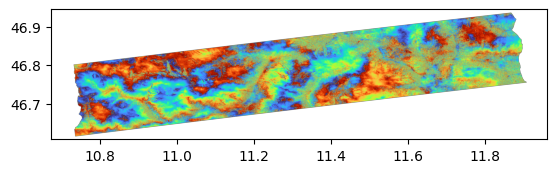

In [13]:
with rasterio.open('phase_coh_20240821T170739_20240902T170739.tif') as src:
    show(src.read(1), transform=src.transform, cmap='turbo')

Visualize the InSAR coherence

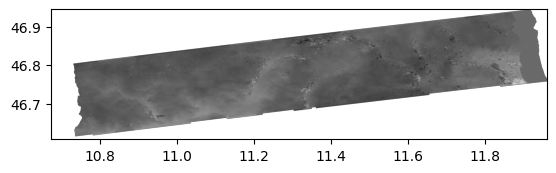

In [14]:
with rasterio.open('phase_coh_20240821T170739_20240902T170739.tif') as src:
    show(src.read(2), transform=src.transform, cmap='gray')

## 2) Visualization in the openEO Web Editor

Open the [OpenEO Web Editor](https://openeo.dataspace.copernicus.eu/), search the job that has been executed and click on *View the results*

![image](https://raw.githubusercontent.com/cloudinsar/s1-workflows/refs/heads/main/notebooks/LPS_DEMO/images/openEO_webeditor.png)

## 3) Visualization in GIS software (QGIS)

Visualize the job result with job.get_results() and click on "Copy URL"

In [15]:
job.get_results()

<JobResults for job 'j-2606081709314d579ed7d3c7ac24b0c4'>

Alternatively the URL can be directly visualized with `job.get_results().get_assets()`

In [16]:
job.get_results().get_assets()

[<ResultAsset 'phase_coh_20240809T170739_20240821T170739.tif' (type application/octet-stream) at 'https://s3.waw3-1.openeo.v1.dataspace.copernicus.eu/openeo-data-prod-waw4-1/batch_jobs/j-2606081709314d579ed7d3c7ac24b0c4/phase_coh_20240809T170739_20240821T170739.tif?X-Proxy-Head-As-Get=true&X-Amz-Algorithm=AWS4-HMAC-SHA256&X-Amz-Credential=28db986326b24d16b8492adb9d94f98b%2F20260608%2Fwaw4-1%2Fs3%2Faws4_request&X-Amz-Date=20260608T195202Z&X-Amz-Expires=86400&X-Amz-SignedHeaders=host&X-Amz-Security-Token=eyJhbGciOiJSUzI1NiIsInR5cCI6IkpXVCJ9.eyJyb2xlX2FybiI6ImFybjpvcGVuZW93czppYW06Ojpyb2xlL29wZW5lby1kYXRhLXByb2Qtd2F3NC0xLXdvcmtzcGFjZSIsImluaXRpYWxfaXNzdWVyIjoib3BlbmVvLnByb2Qud2F3My0xLm9wZW5lby1pbnQudjEuZGF0YXNwYWNlLmNvcGVybmljdXMuZXUiLCJodHRwczovL2F3cy5hbWF6b24uY29tL3RhZ3MiOnsicHJpbmNpcGFsX3RhZ3MiOnsiam9iX2lkIjpbImotMjYwNjA4MTcwOTMxNGQ1NzllZDdkM2M3YWMyNGIwYzQiXSwidXNlcl9pZCI6WyJhNzdkMGMyOC00YTc4LTRjMGMtOGU4NS05MzI2NDNhZDlmNTYiXX0sInRyYW5zaXRpdmVfdGFnX2tleXMiOlsidXNlcl9pZCIsImpvYl9pZCJdfSw

Then open QGIS. Click on *Open Data Source Manager* and select the protocol *HTTPS* as *Source Type*. Then paste the URL and add the layer

![image](https://raw.githubusercontent.com/cloudinsar/s1-workflows/refs/heads/main/notebooks/LPS_DEMO/images/qgis_visualization.png)

## Sentinel-1 InSAR Coherence processing

Create only the coherence using the following process

In [11]:
datacube = connection.datacube_from_process(
  "sentinel1_sar_coherence",
  namespace="https://raw.githubusercontent.com/ESA-APEx/apex_algorithms/refs/heads/main/algorithm_catalog/eurac/sentinel1_sar_coherence/openeo_udp/sentinel1_sar_coherence.json",
   temporal_extent=["2024-08-09", "2024-09-02"],
   temporal_baseline=12,
   burst_id=249435,
   polarization="VV",
   sub_swath="IW2",
   coherence_window_az=2,
   coherence_window_rg=10,
)

datacube = datacube.save_result(format='GTiff')

In [12]:
job = datacube.create_job(title='InSAR_coherence')
job.start_and_wait()
job.get_results().download_files()

0:00:00 Job 'j-2606090906004659b1672130d72bba08': send 'start'
0:00:03 Job 'j-2606090906004659b1672130d72bba08': queued (progress 0%)
0:00:09 Job 'j-2606090906004659b1672130d72bba08': queued (progress 0%)
0:00:15 Job 'j-2606090906004659b1672130d72bba08': queued (progress 0%)
0:00:23 Job 'j-2606090906004659b1672130d72bba08': queued (progress 0%)
0:00:33 Job 'j-2606090906004659b1672130d72bba08': queued (progress 0%)
0:00:45 Job 'j-2606090906004659b1672130d72bba08': queued (progress 0%)
0:01:01 Job 'j-2606090906004659b1672130d72bba08': queued (progress 0%)
0:01:20 Job 'j-2606090906004659b1672130d72bba08': running (progress N/A)
0:01:44 Job 'j-2606090906004659b1672130d72bba08': running (progress N/A)
0:02:14 Job 'j-2606090906004659b1672130d72bba08': running (progress N/A)
0:02:51 Job 'j-2606090906004659b1672130d72bba08': running (progress N/A)
0:03:38 Job 'j-2606090906004659b1672130d72bba08': running (progress N/A)
0:04:36 Job 'j-2606090906004659b1672130d72bba08': running (progress N/A)
0:

[PosixPath('/home/emile/openeo/openeo-community-examples/python/Sentinel1Sar/openEO_2024-08-09Z.tif'),
 PosixPath('/home/emile/openeo/openeo-community-examples/python/Sentinel1Sar/openEO_2024-08-21Z.tif'),
 PosixPath('/home/emile/openeo/openeo-community-examples/python/Sentinel1Sar/job-results.json')]

Visualize the InSAR coherence

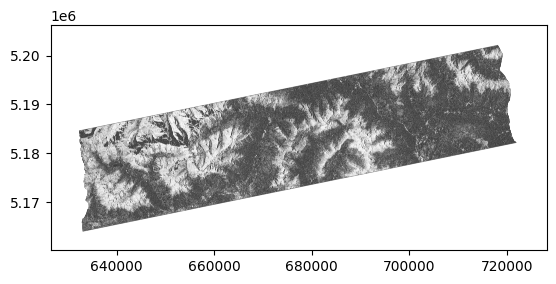

In [15]:
with rasterio.open('openEO_2024-08-21Z.tif') as src:
    show(src.read(1), transform=src.transform, cmap='gray')